# HR Attrition Analysis : Modeling 

## Objective
The primary objective of this study is to build a predictive model to identify employees who are likely to leave the organization based on various demographic, job-related, and performance-related factors.

In [18]:
from sklearn.model_selection import train_test_split
import pandas as pd
df=pd.read_csv("../data/raw/IBM_hr_attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [19]:
X=df.drop("Attrition",axis=1)
y=df['Attrition']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

testing 20% of the data 

Attrition datasets are often imbalanced; stratification ensures both sets represent the original distribution

In [20]:
y.value_counts(normalize=True)


Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [21]:
y_train.value_counts(normalize=True)

Attrition
No     0.838435
Yes    0.161565
Name: proportion, dtype: float64

In [22]:
y_test.value_counts(normalize=True)

Attrition
No     0.840136
Yes    0.159864
Name: proportion, dtype: float64

In [23]:
cat_columns=x_train.select_dtypes(include=["object"]).columns
int_columns=x_train.select_dtypes(exclude=["object"]).columns

In [24]:
cat_columns , int_columns

(Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
        'MaritalStatus', 'Over18', 'OverTime'],
       dtype='object'),
 Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
        'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
        'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
        'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
        'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
        'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
        'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
        'YearsSinceLastPromotion', 'YearsWithCurrManager'],
       dtype='object'))

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer(
    transformers=[("cat",OneHotEncoder(drop="first"),cat_columns),
                  ("int","passthrough",int_columns)]
)

using ColumnTransformer to transform and perform OneHotEncoding to convert categorical columns into numerical columns 
Categorical columns == OneHotEncoding 

Integer/Numerical columns == Passthrough 

In [26]:
preprocessor

ColumnTransformer(transformers=[('cat', OneHotEncoder(drop='first'),
                                 Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')),
                                ('int', 'passthrough',
                                 Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInv...'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object'))])

Fit = deciding the rules

transform = enforcing the rules

always the train data will be used to establish rules 

test data will be used to obtain knowledge of how the model is performing 

In [27]:
x_train_processed=preprocessor.fit_transform(x_train)
x_test_processed=preprocessor.transform(x_test)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),("model",LogisticRegression(max_iter=1000))
])

In [29]:
lr_pipeline.fit(x_train,y_train)

C:\Users\SACCHIT\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')),
                                                 ('int', 'passthrough',
                                                  Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSa...
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [30]:
y_pred=lr_pipeline.predict(x_test)

In [31]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[242   5]
 [ 37  10]]
              precision    recall  f1-score   support

          No       0.87      0.98      0.92       247
         Yes       0.67      0.21      0.32        47

    accuracy                           0.86       294
   macro avg       0.77      0.60      0.62       294
weighted avg       0.84      0.86      0.82       294



In [32]:
y_prob = lr_pipeline.predict_proba(x_test)[:,1]

threshold = 0.30

y_pred_new = ["Yes" if p >= threshold else "No" for p in y_prob]

from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix (Threshold = 0.30)")
print(confusion_matrix(y_test, y_pred_new))

print("\nClassification Report (Threshold = 0.30)")
print(classification_report(y_test, y_pred_new))

Confusion Matrix (Threshold = 0.30)
[[220  27]
 [ 27  20]]

Classification Report (Threshold = 0.30)
              precision    recall  f1-score   support

          No       0.89      0.89      0.89       247
         Yes       0.43      0.43      0.43        47

    accuracy                           0.82       294
   macro avg       0.66      0.66      0.66       294
weighted avg       0.82      0.82      0.82       294



### Threshold Tuning

The dataset is imbalanced, with significantly more employees staying than leaving.

Using the default classification threshold (0.5) resulted in very low recall for the attrition class.

To improve the model's ability to identify employees likely to leave, the decision threshold was lowered to 0.30.

This increased attrition recall from approximately 0.21 to 0.43, allowing the model to detect more at-risk employees while maintaining reasonable overall accuracy.

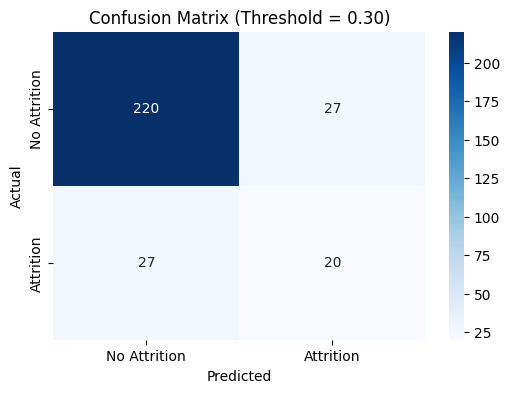

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_new)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition","Attrition"],
            yticklabels=["No Attrition","Attrition"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold = 0.30)")
plt.show()